Ensemble error : 0.034


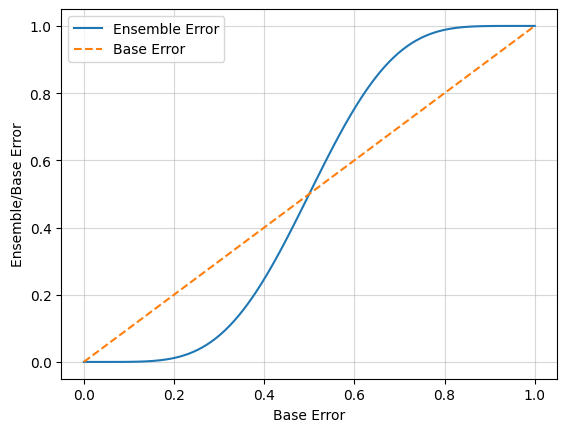

In [11]:
from scipy.special import comb
import math

def ensemble_error(n, error):
    k = int(math.ceil(n/2))
    prob = [comb(n, i)*(error**i)*((1-error)**(n-i)) for i in range(k, n+1)]
    return sum(prob)
print(f"Ensemble error : {ensemble_error(11, 0.25):0.3f}")


import numpy as np
import matplotlib.pyplot as plt

err_range = np.linspace(0.0, 1.0, 100)
ens_error = [ensemble_error(n=11, error=err) for err in err_range]

plt.plot(err_range, ens_error, label="Ensemble Error")
plt.plot(err_range, err_range, linestyle='--', label='Base Error')
plt.xlabel("Base Error")
plt.ylabel("Ensemble/Base Error")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

# Ensemble always performs better until the base error is less than random guess (error < 0.5)

In [6]:
# Majority Vote Classifier
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import _name_estimators
import operator

class MajorityVotingClassifier(ClassifierMixin, BaseEstimator):

    def __init__(self, classifiers, vote='classlabel', weights=None):
        self.classifiers = classifiers
        self.vote = vote
        self.weights = weights
        self.named_classifiers = {key: value for key, value in _name_estimators(classifiers)}


    def fit(self, X_train, y_train):
        self.classifiers_ = []

        self.lc_ = LabelEncoder()
        self.lc_.fit(y_train)

        self.classes_ = self.lc_.classes_

        for clf in self.classifiers:
            clf_t = clone(clf).fit(X_train, self.lc_.transform(y_train))
            self.classifiers_.append(clf_t)

        return self


    def predict(self, X_test):
       
        if self.vote == 'probability':
            maj_vote = np.argmax(self.predict_proba(X_test), axis=1)
        else:
            prediction = []
            for clf in self.classifiers_:
                prediction.append(clf.predict(X_test))

            prediction = np.asarray(prediction).T
            maj_vote = []

            for row in prediction:
                temp = np.bincount(row, weights=self.weights)
                temp = np.argmax(temp)
                maj_vote.append(temp)

            maj_vote = np.asarray(maj_vote)

        maj_vote = self.lc_.inverse_transform(maj_vote)  

        return maj_vote


    def predict_proba(self, X):
        probas = []
        for clf in self.classifiers_:
            probas.append(clf.predict_proba(X))

        probas = np.asarray(probas)
        avg_proba = np.average(probas, axis=0, weights=self.weights)

        return avg_proba

    def get_params(self, deep=True):
        out = super().get_params(deep=False)

        if deep:
            # out.update(self.named_classifiers)
            out = self.named_classifiers.copy()
            for name, model in self.named_classifiers.items():
                for key, value in model.get_params(deep=True).items():
                    out[f"{name}__{key}"] = value
                    
        return out

In [7]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

iris = datasets.load_iris()
X, y = iris.data[50:, [1,2]], iris.target[50:]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1, stratify=y)

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import numpy as np

clf1 = LogisticRegression(l1_ratio=0, C=0.001, random_state=1,solver='lbfgs')
clf2 = DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=1)
clf3 = KNeighborsClassifier(n_neighbors=1, metric='minkowski', p=2)

pipe1 = Pipeline([('sc', StandardScaler()), ('clf', clf1)])
pipe3 = Pipeline([('sc', StandardScaler()), ('clf', clf3)])

clf_labels = ['Logistic Regression', 'Decision Tree', 'KNN']

print(f"10 Fold Cross-Validation : ")
for clf, label in zip([pipe1, clf2, pipe3], clf_labels):
    scores = cross_val_score(clf, X=X_train, y=y_train, cv=10, scoring='roc_auc')
    print(f"ROC-AUC for {label}: {scores.mean():0.2f} +/- ({scores.std():0.2f})")

10 Fold Cross-Validation : 
ROC-AUC for Logistic Regression: 0.92 +/- (0.15)
ROC-AUC for Decision Tree: 0.87 +/- (0.18)
ROC-AUC for KNN: 0.85 +/- (0.13)


In [8]:
# Combining and comparing Majority Voting Classifier with individual classifiers
mv_clf = MajorityVotingClassifier([pipe1, clf2, pipe3])

all_clf = [pipe1, clf2, pipe3, mv_clf]
clf_labels.append('Majority Voting Classifier')
print(f"10 Fold Cross-Validation : ")

for clf, label in zip(all_clf, clf_labels):
    scores = cross_val_score(estimator=clf, X=X_train, y=y_train, cv=10, scoring='roc_auc')
    print(f"ROC-AUC for {label}: {scores.mean():0.2f} +/- {scores.std():0.2f}")

10 Fold Cross-Validation : 
ROC-AUC for Logistic Regression: 0.92 +/- 0.15
ROC-AUC for Decision Tree: 0.87 +/- 0.18
ROC-AUC for KNN: 0.85 +/- 0.13
ROC-AUC for Majority Voting Classifier: 0.98 +/- 0.05


In [9]:
print(MajorityVotingClassifier.__mro__)

(<class '__main__.MajorityVotingClassifier'>, <class 'sklearn.base.ClassifierMixin'>, <class 'sklearn.base.BaseEstimator'>, <class 'sklearn.utils._repr_html.base.ReprHTMLMixin'>, <class 'sklearn.utils._repr_html.base._HTMLDocumentationLinkMixin'>, <class 'sklearn.utils._metadata_requests._MetadataRequester'>, <class 'object'>)


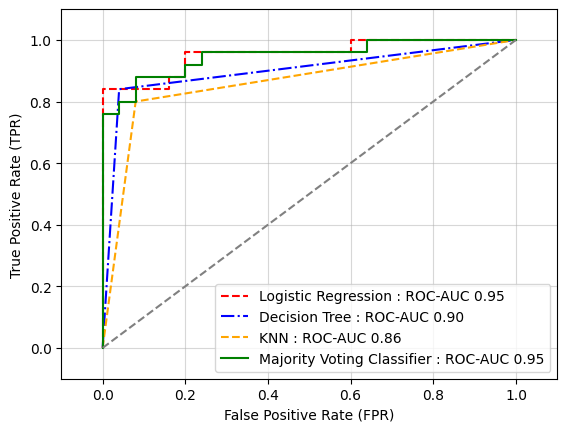

In [12]:
from sklearn.metrics import roc_curve, auc

colors = ['red', 'blue', 'orange', 'green']
line_style = ['--', '-.', '--', '-']

for clf, label, col, ls in zip(all_clf, clf_labels, colors, line_style):
    clf.fit(X_train, y_train)
    y_pred = clf.predict_proba(X_test)[:, 1]

    fpr, tpr, threshold = roc_curve(y_true=y_test, y_score=y_pred)
    roc_auc = auc(x=fpr, y=tpr)
    plt.plot(fpr, tpr, label=f"{label} : ROC-AUC {roc_auc:0.2f}", color=col, linestyle=ls)

plt.plot([0,1], [0,1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.grid(alpha=0.5)
plt.show()

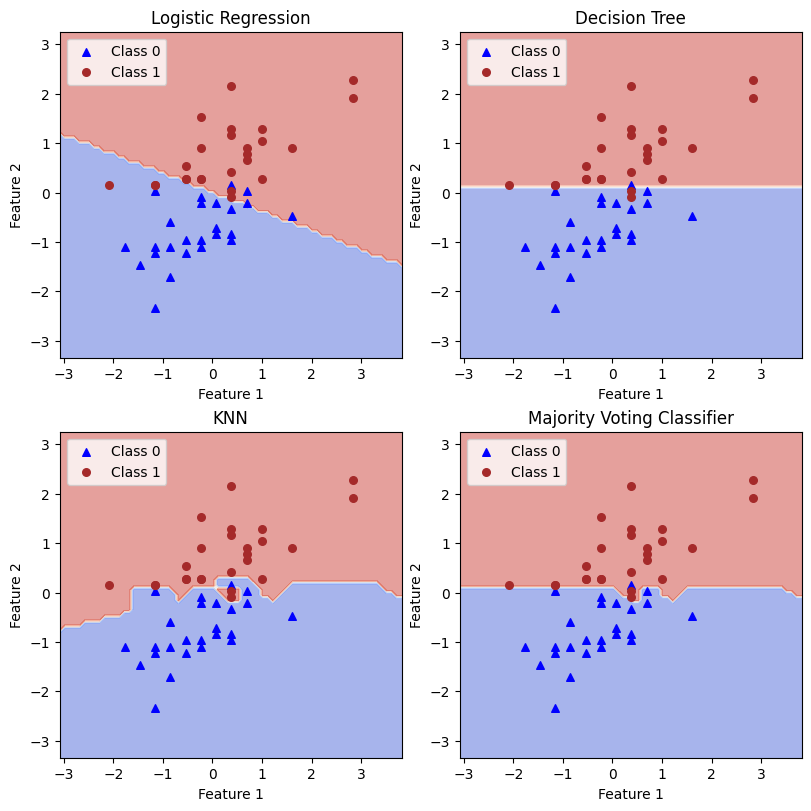

In [13]:
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)

h_min, h_max = X_train_std[:, 0].min() - 1, X_train_std[:, 0].max() + 1
v_min, v_max = X_train_std[:, 1].min() - 1, X_train_std[:, 1].max() + 1

hh, vv = np.meshgrid(np.arange(h_min, h_max, 0.1), np.arange(v_min, v_max, 0.1))
grid = np.column_stack([hh.ravel(), vv.ravel()])

fig, axarr = plt.subplots(2, 2, figsize = (8,8), constrained_layout=True)
axarr = axarr.ravel()

for ax, clf, label in zip(axarr, all_clf, clf_labels):
    clf.fit(X_train_std, y_train)
    z = clf.predict(grid)
    z = z.reshape(hh.shape)

    ax.contourf(hh, vv, z, alpha=0.5, cmap='coolwarm')
    ax.scatter(X_train_std[y_train==0, 0], X_train_std[y_train==0, 1], marker='^', label='Class 0', 
               color='blue', s=30)
    ax.scatter(X_train_std[y_train==1, 0], X_train_std[y_train==1, 1], marker='o', label='Class 1',
               color='brown', s=30)

    ax.set_title(label)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()

plt.show()

In [14]:
mv_clf.get_params()

{'pipeline-1': Pipeline(steps=[('sc', StandardScaler()),
                 ('clf',
                  LogisticRegression(C=0.001, l1_ratio=0, random_state=1))]),
 'decisiontreeclassifier': DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=1),
 'pipeline-2': Pipeline(steps=[('sc', StandardScaler()),
                 ('clf', KNeighborsClassifier(n_neighbors=1))]),
 'pipeline-1__memory': None,
 'pipeline-1__steps': [('sc', StandardScaler()),
  ('clf', LogisticRegression(C=0.001, l1_ratio=0, random_state=1))],
 'pipeline-1__transform_input': None,
 'pipeline-1__verbose': False,
 'pipeline-1__sc': StandardScaler(),
 'pipeline-1__clf': LogisticRegression(C=0.001, l1_ratio=0, random_state=1),
 'pipeline-1__sc__copy': True,
 'pipeline-1__sc__with_mean': True,
 'pipeline-1__sc__with_std': True,
 'pipeline-1__clf__C': 0.001,
 'pipeline-1__clf__class_weight': None,
 'pipeline-1__clf__dual': False,
 'pipeline-1__clf__fit_intercept': True,
 'pipeline-1__clf__intercept_scaling': 1,

In [16]:
from sklearn.model_selection import GridSearchCV
params_gd = {'decisiontreeclassifier__max_depth': [2, 5, 8], 
          'pipeline-1__clf__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

grid = GridSearchCV(estimator=mv_clf, param_grid=params_gd, cv=10, scoring='roc_auc')
grid.fit(X_train, y_train)

for mean, std, params in zip(grid.cv_results_['mean_test_score'],
                             grid.cv_results_['std_test_score'],
                             grid.cv_results_['params']):
    print(f"{mean:0.3f} +/- {std:0.3f} for {params}")

print(f'Best parameters: {grid.best_params_}')
print(f'ROC AUC : {grid.best_score_:.3f}')

0.983 +/- 0.050 for {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.001}
0.983 +/- 0.050 for {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.01}
0.983 +/- 0.050 for {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.1}
0.967 +/- 0.100 for {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 1.0}
0.967 +/- 0.100 for {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 10.0}
0.967 +/- 0.100 for {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 100.0}
0.983 +/- 0.050 for {'decisiontreeclassifier__max_depth': 5, 'pipeline-1__clf__C': 0.001}
0.983 +/- 0.050 for {'decisiontreeclassifier__max_depth': 5, 'pipeline-1__clf__C': 0.01}
0.983 +/- 0.050 for {'decisiontreeclassifier__max_depth': 5, 'pipeline-1__clf__C': 0.1}
0.967 +/- 0.100 for {'decisiontreeclassifier__max_depth': 5, 'pipeline-1__clf__C': 1.0}
0.967 +/- 0.100 for {'decisiontreeclassifier__max_depth': 5, 'pipeline-1__clf__C': 10.0}
0.967 +/- 0.100 for {'

In [ ]:
print(mv_clf.get_params(deep=True).keys())